# ASSIGNMENT 7
## GAN for Image Generation

In [1]:
# %pip install tensorflow numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') - 127.5)/127.5
x_train = x_train[..., np.newaxis]
train_ds = tf.data.Dataset.from_tensor_slices(x_train).shuffle(x_train.shape[0]).batch(256)
noise_dim = 100

In [3]:
def make_generator():
    return tf.keras.Sequential([
        layers.Input(shape=(noise_dim,)),
        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7,7,256)),
        layers.Conv2DTranspose(128, 5, strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(1, 5, strides=2, padding='same', use_bias=False, activation='tanh')
    ])

def make_discriminator():
    return tf.keras.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(64, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1)
    ])

g = make_generator()
d = make_discriminator()

In [4]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
go = tf.keras.optimizers.Adam(1e-4)
do = tf.keras.optimizers.Adam(1e-4)

def d_loss(real_out, fake_out):
    return bce(tf.ones_like(real_out), real_out) + bce(tf.zeros_like(fake_out), fake_out)

def g_loss(fake_out):
    return bce(tf.ones_like(fake_out), fake_out)

@tf.function
def step(images):
    noise = tf.random.normal([tf.shape(images)[0], noise_dim])
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake = g(noise, training=True)
        real_out = d(images, training=True)
        fake_out = d(fake, training=True)
        gl = g_loss(fake_out)
        dl = d_loss(real_out, fake_out)
    go.apply_gradients(zip(gt.gradient(gl, g.trainable_variables), g.trainable_variables))
    do.apply_gradients(zip(dt.gradient(dl, d.trainable_variables), d.trainable_variables))
    return gl, dl

In [ ]:
epochs = 10
for e in range(epochs):
    gls, dls, n = 0.0, 0.0, 0
    for batch in train_ds:
        gl, dl = step(batch)
        gls += float(gl); dls += float(dl); n += 1
    print(f'Epoch {e+1}/{epochs} | G: {gls/n:.4f} | D: {dls/n:.4f}')

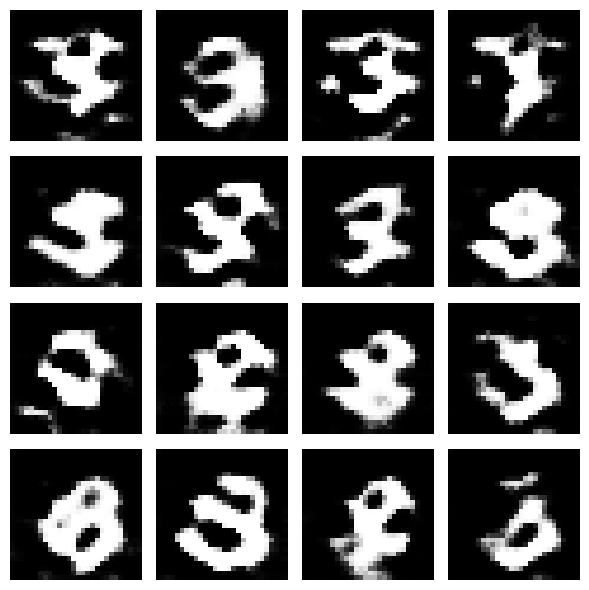

In [ ]:
seed = tf.random.normal([16, noise_dim])
imgs = g(seed, training=False).numpy()
plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow((imgs[i,:,:,0]+1)/2, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()